# Лабораторная работа №2
# Классификация вин с помощью нейронной сети
# Цель: Достичь точности >94% на тестовой выборке


### Задание

Используя модуль **datasets** библиотеки **sklearn**, загрузите базу вин (`.load_wine()`).

Используя шаблон ноутбука, выполните загрузку, подготовку и предобработку данных. Обязательное условие: разделение данных на три выборки осуществляется по шаблону (изменять параметры подготовки данных запрещается)!

Проведите серию экспериментов и добейтесь максимальной точности классификации на тестовой выборке выше 94%.

---

С помощью метода `.summary()` зафиксируйте количество параметров созданной вами нейронной сети.


# 1. Импорт необходимых библиотек

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import utils
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# 2. Загрузка датасета





In [2]:
# Загрузка данных о винах
wine_data = load_wine()
x_data = wine_data['data']
y_data = wine_data['target']

print('Размер x_data:', x_data.shape)
print('Размер y_data:', y_data.shape)
print('\nНазвания признаков:', wine_data['feature_names'])
print('Названия классов:', wine_data['target_names'])
print('\nПервый образец:', x_data[0])
print('Класс первого образца:', y_data[0])

Размер x_data: (178, 13)
Размер y_data: (178,)

Названия признаков: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Названия классов: ['class_0' 'class_1' 'class_2']

Первый образец: [1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
 2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
Класс первого образца: 0


# 3. Подготовка данных (фиксированный шаблон)



In [3]:
# Преобразование в one-hot encoding (3 класса)
y_data = utils.to_categorical(y_data, 3)

# Разделение на общую и тестовую выборки (90% / 10%)
x_all, x_test, y_all, y_test = train_test_split(
    x_data,
    y_data,
    test_size=0.1,
    shuffle=True,
    random_state=6
)

# Разделение общей выборки на обучающую и валидационную (90% / 10%)
x_train, x_val, y_train, y_val = train_test_split(
    x_all,
    y_all,
    test_size=0.1,
    shuffle=True,
    random_state=6
)

print('Обучающая выборка:', x_train.shape, y_train.shape)
print('Валидационная выборка:', x_val.shape, y_val.shape)
print('Тестовая выборка:', x_test.shape, y_test.shape)

Обучающая выборка: (144, 13) (144, 3)
Валидационная выборка: (16, 13) (16, 3)
Тестовая выборка: (18, 13) (18, 3)


# 4. Предобработка данных (масштабирование)

In [4]:
# Стандартизация признаков для ускорения сходимости
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

print('\nПосле масштабирования:')
print('Среднее обучающей выборки:', x_train_scaled.mean(axis=0).round(3))
print('Стандартное отклонение:', x_train_scaled.std(axis=0).round(3))


После масштабирования:
Среднее обучающей выборки: [ 0. -0.  0. -0. -0.  0. -0.  0.  0.  0.  0.  0. -0.]
Стандартное отклонение: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# 5. Создание архитектуры нейронной сети

In [5]:
model = Sequential([
    # Входной слой (13 признаков) + первый скрытый слой
    Dense(128, input_shape=(13,), activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Второй скрытый слой
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Третий скрытый слой
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    # Выходной слой (3 класса, softmax)
    Dense(3, activation='softmax')
])

# Вывод архитектуры с количеством параметров
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,123 (51.26 KB)

 Trainable params: 12,675 (49.51 KB)

 Non-trainable params: 448 (1.75 KB)

# 6. Компиляция модели

In [6]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 7. Обучение модели

In [7]:
# Ранняя остановка для предотвращения переобучения
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    x_train_scaled,
    y_train,
    validation_data=(x_val_scaled, y_val),
    epochs=500,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step - accuracy: 0.4931 - loss: 1.1283 - val_accuracy: 0.3750 - val_loss: 1.0873
Epoch 2/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7431 - loss: 0.6483 - val_accuracy: 0.8125 - val_loss: 0.9065
Epoch 3/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8472 - loss: 0.4560 - val_accuracy: 0.8750 - val_loss: 0.7777
Epoch 4/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8750 - loss: 0.3265 - val_accuracy: 0.8750 - val_loss: 0.6870
Epoch 5/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9167 - loss: 0.2955 - val_accuracy: 0.8750 - val_loss: 0.6093
Epoch 6/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9375 - loss: 0.2411 - val_accuracy: 0.8750 - val_loss: 0.5439
Epoch 7/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9653 - loss: 0.1651 - val_accuracy: 0.9375 - val_loss: 0.4900
Epoch 8/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9514 - loss: 0.1709 - val_accuracy: 0.9375 - val_loss

# 8. Визуализация обучения

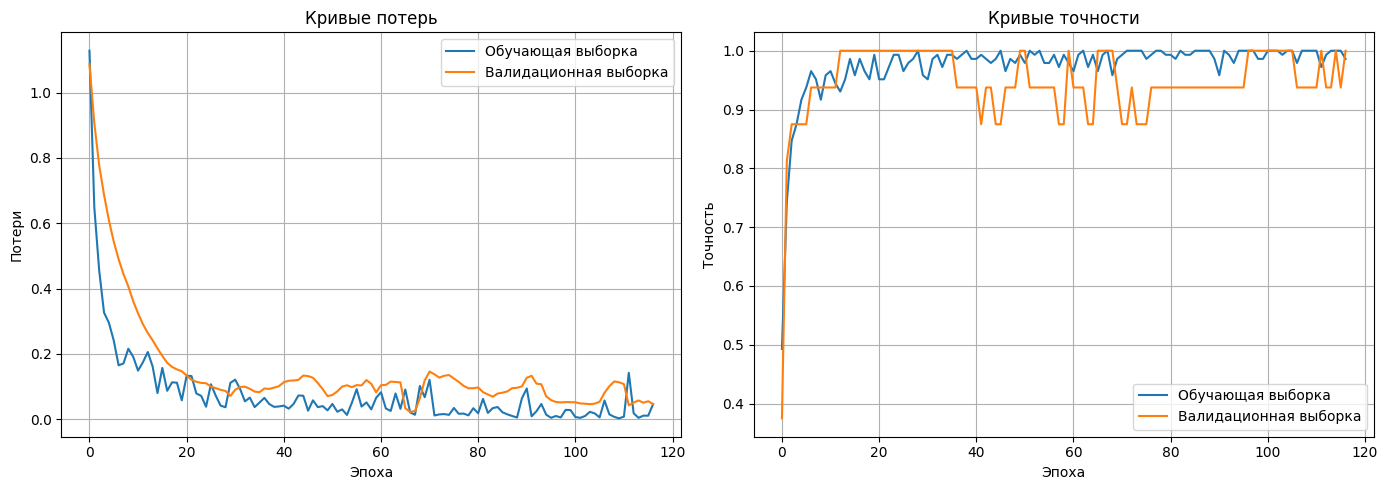

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График потерь
axes[0].plot(history.history['loss'], label='Обучающая выборка')
axes[0].plot(history.history['val_loss'], label='Валидационная выборка')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Потери')
axes[0].set_title('Кривые потерь')
axes[0].legend()
axes[0].grid(True)

# График точности
axes[1].plot(history.history['accuracy'], label='Обучающая выборка')
axes[1].plot(history.history['val_accuracy'], label='Валидационная выборка')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Точность')
axes[1].set_title('Кривые точности')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# 9. Оценка качества модели

In [9]:
# Оценка на тестовой выборке
test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f'\nПотери на тесте: {test_loss:.4f}')
print(f'Точность на тесте: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

# Оценка на валидационной выборке
val_loss, val_accuracy = model.evaluate(x_val_scaled, y_val, verbose=0)
print(f'Точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)')


Потери на тесте: 0.0030
Точность на тесте: 1.0000 (100.00%)
Точность на валидации: 1.0000 (100.00%)


# 10. Детальный анализ предсказаний

In [10]:
# Получение предсказаний
y_pred = model.predict(x_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Матрица ошибок и отчёт о классификации
from sklearn.metrics import confusion_matrix, classification_report

print('\nМатрица ошибок:')
print(confusion_matrix(y_true_classes, y_pred_classes))

print('\nОтчёт о классификации:')
print(classification_report(y_true_classes, y_pred_classes,
                           target_names=wine_data['target_names']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step

Матрица ошибок:
[[9 0 0]
 [0 8 0]
 [0 0 1]]

Отчёт о классификации:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00         9
     class_1       1.00      1.00      1.00         8
     class_2       1.00      1.00      1.00         1

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



# 11. Подсчёт параметров модели

In [11]:
print('ПОДСЧЁТ ПАРАМЕТРОВ')

total_params = 0
for i, layer in enumerate(model.layers):
    params = layer.count_params()
    total_params += params
    print(f'Слой {i+1}: {layer.name} - {params:,} параметров')

print(f'ВСЕГО ПАРАМЕТРОВ: {total_params:,}')

# Проверка соответствия с model.summary()
assert total_params == model.count_params()
print('\nКоличество параметров подтверждено model.summary()!')

ПОДСЧЁТ ПАРАМЕТРОВ
Слой 1: dense - 1,792 параметров
Слой 2: batch_normalization - 512 параметров
Слой 3: dropout - 0 параметров
Слой 4: dense_1 - 8,256 параметров
Слой 5: batch_normalization_1 - 256 параметров
Слой 6: dropout_1 - 0 параметров
Слой 7: dense_2 - 2,080 параметров
Слой 8: batch_normalization_2 - 128 параметров
Слой 9: dropout_2 - 0 параметров
Слой 10: dense_3 - 99 параметров
ВСЕГО ПАРАМЕТРОВ: 13,123

Количество параметров подтверждено model.summary()!


# 12. Итоговые результаты

In [12]:
print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ')

print(f'Лучшая точность на валидации: {max(history.history["val_accuracy"]):.4f}')
print(f'Точность на тестовой выборке: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'Потери на тестовой выборке: {test_loss:.4f}')
print(f'Общее количество параметров: {total_params:,}')
print(f'Цель достигнута (точность > 94%): {"ДА" if test_accuracy > 0.94 else "НЕТ"}')


# Дополнительный вывод для отчёта
print('\nАрхитектура модели:')
print(f'  - Входной слой: 13 нейронов')
print(f'  - Скрытый слой 1: 128 нейронов (ReLU) + BatchNorm + Dropout 0.3')
print(f'  - Скрытый слой 2: 64 нейрона (ReLU) + BatchNorm + Dropout 0.2')
print(f'  - Скрытый слой 3: 32 нейрона (ReLU) + BatchNorm + Dropout 0.1')
print(f'  - Выходной слой: 3 нейрона (Softmax)')
print(f'  - Оптимизатор: Adam (lr=0.001)')
print(f'  - Функция потерь: Categorical Crossentropy')

ИТОГОВЫЕ РЕЗУЛЬТАТЫ
Лучшая точность на валидации: 1.0000
Точность на тестовой выборке: 1.0000 (100.00%)
Потери на тестовой выборке: 0.0030
Общее количество параметров: 13,123
Цель достигнута (точность > 94%): ДА

Архитектура модели:
  - Входной слой: 13 нейронов
  - Скрытый слой 1: 128 нейронов (ReLU) + BatchNorm + Dropout 0.3
  - Скрытый слой 2: 64 нейрона (ReLU) + BatchNorm + Dropout 0.2
  - Скрытый слой 3: 32 нейрона (ReLU) + BatchNorm + Dropout 0.1
  - Выходной слой: 3 нейрона (Softmax)
  - Оптимизатор: Adam (lr=0.001)
  - Функция потерь: Categorical Crossentropy
